<a href="https://colab.research.google.com/github/Yae-sine/AI_PLayground/blob/main/TextMining/Mini_Projet/collab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.3 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score , KFold
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , f1_score
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from keras.models import Sequential
from keras.layers import Dense
import re
from gensim.models import Word2Vec , FastText

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Open the file first with error handling, then pass to pandas
with open('/content/drive/MyDrive/Collab_TextMining_MiniProjet/reviews.tsv', 'r', encoding='utf-8', errors='ignore') as f:

# with open('/content/reviews.tsv', 'r', encoding='utf-8', errors='ignore') as f:
    df = pd.read_csv(f, sep='\t')
print(df.shape)
print(df.head())
print(df["label"].value_counts())

(99999, 2)
      label                                               text
0  Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1  Positive  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2  Positive  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3  Positive  خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4  Positive  ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   99999 non-null  object
 1   text    99999 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None
           label                                               text
count      99999                                              99999
unique         3                                              99999
top     Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
freq       33333                                                  1


In [5]:
df["length"] = df["text"].astype(str).str.split().apply(len)
display(df["length"].describe())

display(df.groupby("label")["length"].describe())

,length
count,99999.000000
mean,55.026010
std,95.495538
min,1.000000
25%,13.000000
50%,26.000000
75%,57.000000
max,1663.000000


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Mixed,33333.0,55.701317,92.953663,1.0,13.0,27.0,59.0,1663.0
Negative,33333.0,55.021120,93.352397,1.0,13.0,28.0,58.0,1622.0
Positive,33333.0,54.355594,100.013906,1.0,11.0,24.0,54.0,1580.0


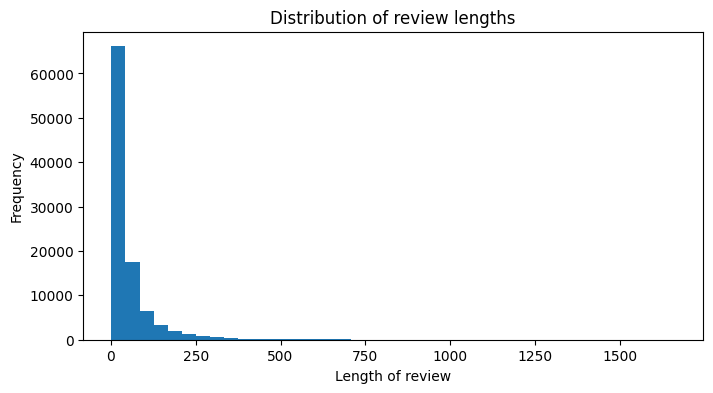

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df["length"] , bins = 40)
plt.title("Distribution of review lengths")
plt.xlabel("Length of review")
plt.ylabel("Frequency")
plt.show()


In [4]:
def clean_arabic_text(text):
    # Convert to string and strip spaces
    text = str(text).strip()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove punctuations and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove Arabic diacritics (Harakat)
    tashkeel = re.compile(r'[\u064B-\u0652]')
    text = re.sub(tashkeel, '', text)
    # Remove elongations (e.g., "مبروووك" to "مبروك")
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return text


def remove_punctuation(text):
    # This removes all punctuation including dots (.) and commas (،)
    # [^\w\s] matches anything that is NOT a word character or whitespace
    clean_text = re.sub(r'[^\w\s]', '', str(text))
    # Replace multiple spaces with a single space
    return " ".join(clean_text.split())


# Apply it to your dataframe
df["text"] = df["text"].apply(remove_punctuation)
# Apply the cleaning function to your text column
df["text"] = df["text"].apply(clean_arabic_text)

In [5]:
df["label"] = df["label"].map({"Negative": 0 , "Mixed": 2 , "Positive": 1})
df.head()


,label,text
0,1,ممتاز نوعا ما النظافة والموقع والتجهيز والشاطي...
1,1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,1,هادفة وقوية تنقلك من صخب شوارع القاهرة الى هدو...
3,1,خلصنا مبدئيا اللي مستني ابهار زي الفيل الازرق ...
4,1,ياسات جلوريا جزء لا يتجزأ من دبي فندق متكامل ا...


In [8]:
X = df["text"]
y = df["label"]

X_train , X_test , y_train , y_test = train_test_split(X ,y ,test_size=0.2 ,random_state=42 , stratify=y)

# **BagOfWords**

In [8]:
vectorizer = CountVectorizer( max_features= 3000) # Optional: limit features to save memory
X_train_bow = vectorizer.fit_transform(X_train).toarray()
X_test_bow = vectorizer.transform(X_test).toarray()

# 2. Ensure y is also a numpy array
y_train_np = np.array(y_train)

# 3. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_bow.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train using the numpy versions
model.fit(X_train_bow, y_train_np, epochs=100, batch_size=20)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6396 - loss: 0.7767
Epoch 2/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7055 - loss: 0.6567
Epoch 3/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7777 - loss: 0.5193
Epoch 4/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8572 - loss: 0.3564
Epoch 5/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9132 - loss: 0.2314
Epoch 6/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9442 - loss: 0.1567
Epoch 7/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9596 - loss: 0.1173
Epoch 8/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9700 - loss: 0.0898
Epoch 9/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9749 - loss: 0.0761
Epoch 10/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9791 - loss: 0.0653
Epoch 11/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9820 - loss: 0.0552
Epoch 12

In [9]:
y_pred = model.predict(X_test_bow)
print(classification_report(y_test, y_pred.argmax(axis=1)))
print(confusion_matrix(y_test, y_pred.argmax(axis=1)))

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.65      0.64      0.65      6666
           1       0.65      0.62      0.64      6667
           2       0.52      0.55      0.54      6667

    accuracy                           0.61     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.61      0.61      0.61     20000

[[4265  713 1688]
 [ 778 4162 1727]
 [1470 1511 3686]]



---

# **Ngram**
---



In [11]:
vectorizer_ngram = CountVectorizer(ngram_range = (1 , 2) , max_features= 2000)
X_train_ngram = vectorizer_ngram.fit_transform(X_train).toarray()
X_test_ngram = vectorizer_ngram.transform(X_test).toarray()

# 2. Ensure y is also a numpy array
y_train_np = np.array(y_train)

# 3. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ngram.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train using the numpy versions
model.fit(X_train_ngram, y_train_np, epochs=25, batch_size=20)



Epoch 1/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6362 - loss: 0.7804
Epoch 2/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6949 - loss: 0.6762
Epoch 3/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7500 - loss: 0.5724
Epoch 4/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8195 - loss: 0.4360
Epoch 5/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8772 - loss: 0.3123
Epoch 6/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9139 - loss: 0.2273
Epoch 7/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9370 - loss: 0.1722
Epoch 8/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9503 - loss: 0.1372
Epoch 9/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9611 - loss: 0.1114
Epoch 10/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9663 - loss: 0.0975
Epoch 11/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9704 - loss: 0.0836
Epoch 12/25
4000/40

In [12]:
y_pred_ngram = model.predict(X_test_ngram)
print(classification_report(y_test, y_pred_ngram.argmax(axis=1)))
print(confusion_matrix(y_test, y_pred_ngram.argmax(axis=1)))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.67      0.63      0.65      6666
           1       0.64      0.66      0.65      6667
           2       0.53      0.54      0.53      6667

    accuracy                           0.61     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.61      0.61      0.61     20000

[[4177  856 1633]
 [ 700 4389 1578]
 [1401 1664 3602]]


# **Tf-IDF**

In [13]:
tfidf = TfidfVectorizer(max_features=1000)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_tfidf, y_train, epochs=25, batch_size=20)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6218 - loss: 0.7967
Epoch 2/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6634 - loss: 0.7322
Epoch 3/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6995 - loss: 0.6752
Epoch 4/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7485 - loss: 0.5911
Epoch 5/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7997 - loss: 0.4883
Epoch 6/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8461 - loss: 0.3879
Epoch 7/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8810 - loss: 0.3051
Epoch 8/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9064 - loss: 0.2416
Epoch 9/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9249 - loss: 0.1963
Epoch 10/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9377 - loss: 0.1638
Epoch 11/25
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9459 - loss: 0.1406
Epoch 12/25
4000/40

In [14]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred.argmax(axis=1)))
print(confusion_matrix(y_test, y_pred.argmax(axis=1)))

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0       0.63      0.63      0.63      6666
           1       0.61      0.64      0.63      6667
           2       0.52      0.50      0.51      6667

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000

[[4167  975 1524]
 [ 910 4272 1485]
 [1590 1754 3323]]


# **Word2Vec**




In [15]:
X_train_tokens = [s.lower().split() for s in X_train]
X_test_tokens = [s.lower().split() for s in X_test]

In [16]:
def get_average_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [17]:
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)


X_train_vec = np.array([get_average_vector(t, w2v_model) for t in X_train_tokens])
X_test_vec = np.array([get_average_vector(t, w2v_model) for t in X_test_tokens])

# 5. Build Keras Sequential Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(100,)), # Input matches vector_size
    Dense(64, activation='relu'),
    Dense(3, activation='softmax') # 3 classes for Positive, Mixed, Negative
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Train and Evaluate
model.fit(X_train_vec, y_train, epochs=25, batch_size=32, verbose=1)

y_pred_word2Vec = model.predict(X_test_vec)
print(classification_report(y_test, y_pred_word2Vec.argmax(axis=1)))
print(confusion_matrix(y_test, y_pred_word2Vec.argmax(axis=1)))

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5919 - loss: 0.8549
Epoch 2/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6164 - loss: 0.8132
Epoch 3/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6246 - loss: 0.7990
Epoch 4/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6299 - loss: 0.7888
Epoch 5/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6352 - loss: 0.7812
Epoch 6/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6387 - loss: 0.7748
Epoch 7/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6417 - loss: 0.7680
Epoch 8/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6448 - loss: 0.7619
Epoch 9/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6471 - loss: 0.7570
Epoch 10/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6512 - loss: 0.7513
Epoch 11/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6542 - loss: 0.7453
Epoch 12/25
2500/2500 ━━━━━━━━━━━━━━━━━━

# **FastText**

In [18]:
fastText = FastText(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)

X_train_FT = np.array([get_average_vector(t, fastText) for t in X_train_tokens])
X_test_FT = np.array([get_average_vector(t, fastText) for t in X_test_tokens])

# 5. Build Keras Sequential Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(100,)), # Input matches vector_size
    Dense(64, activation='relu'),
    Dense(3, activation='softmax') # 3 classes for Positive, Mixed, Negative
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Train and Evaluate
model.fit(X_train_FT, y_train, epochs=25, batch_size=32, verbose=1)

y_pred_FT = model.predict(X_test_FT)
print(classification_report(y_test, y_pred_FT.argmax(axis=1)))
print(confusion_matrix(y_test, y_pred_FT.argmax(axis=1)))

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5820 - loss: 0.8718
Epoch 2/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6081 - loss: 0.8287
Epoch 3/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6152 - loss: 0.8139
Epoch 4/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6233 - loss: 0.8024
Epoch 5/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6270 - loss: 0.7947
Epoch 6/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6298 - loss: 0.7866
Epoch 7/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6338 - loss: 0.7807
Epoch 8/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6382 - loss: 0.7734
Epoch 9/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6413 - loss: 0.7680
Epoch 10/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6451 - loss: 0.7619
Epoch 11/25
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6482 - loss: 0.7565
Epoch 12/25
2500/2500 ━━━━━━━━━━━━━━━━━━━

# **Cleaning the text (Stemming - removing emojies -punctuation - normalisation (alif)...)**

In [3]:
%pip install pandas nltk emoji tashaphyne camel-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.5/251.5 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.9 MB/s eta 0:00:00
  

In [6]:
import string
import emoji
import nltk
from nltk.corpus import stopwords
from tashaphyne.stemming import ArabicLightStemmer
from camel_tools.utils.dediac import dediac_ar
from camel_tools.utils.normalize import normalize_alef_ar, normalize_teh_marbuta_ar, normalize_alef_maksura_ar
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

# Download NLTK stopwords if not present
nltk.download('stopwords')

# Initialize Tools
stop_words = set(stopwords.words('arabic'))
light_stemmer = ArabicLightStemmer()

# Initialize CAMeL Tools for Lemmatization (requires installed data)
# We use a simple analyzer here; for best results use the MLEDisambiguator
try:
    db = MorphologyDB.builtin_db()
    analyzer = Analyzer(db)
except:
    print("CAMeL Tools data not found. Lemmatization step will be skipped.")
    analyzer = None

def clean_arabic_text(text):
    # A. Remove Emojis
    text = emoji.replace_emoji(text, replace='')

    # B. Dediacritization (Remove Tashkeel: Fatha, Damma, etc.)
    # Using CAMeL Tools is safer than regex for all diacritics
    text = dediac_ar(text)

    # C. Orthographic Normalization
    text = normalize_alef_ar(text)          # Unify (أ، إ، آ) -> (ا)
    text = normalize_alef_maksura_ar(text)  # Unify (ى) -> (ي)
    text = normalize_teh_marbuta_ar(text)   # Unify (ة) -> (ه)

    # D. Remove Punctuation (Arabic & English)
    # Define Arabic punctuation marks not included in string.punctuation
    arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
    english_punctuations = string.punctuation
    all_punctuations = set(arabic_punctuations + english_punctuations)

    text = ''.join([char for char in text if char not in all_punctuations])

    # E. Remove Numbers (Optional - depends on use case)
    text = re.sub(r'\d+', '', text)

    return text

def preprocess_tokens(text, operation='stem'):
    tokens = text.split()

    # F. Remove Stopwords
    tokens = [w for w in tokens if w not in stop_words]

    if operation == 'light_stem':
        # G. Light Stemming (Removes prefixes/suffixes: 'والكتاب' -> 'كتاب')
        return [light_stemmer.light_stem(w) for w in tokens]

    elif operation == 'lemma' and analyzer:
        # H. Lemmatization (Get root/dictionary form: 'كتاب' -> 'كَتَبَ' or 'كِتَاب')
        # CAMeL Tools analyzer returns list of analyses; we take the first lemma for simplicity
        lemmas = []
        for w in tokens:
            analyses = analyzer.analyze(w)
            if analyses:
                # Ideally use a Disambiguator here, but taking top result is a common simple baseline
                lemmas.append(analyses[0].get('lex', 'unknown').split('_')[0])
            else:
                lemmas.append(w)
        return lemmas

    return tokens

# --- APPLYING TO DATAFRAME ---

# 1. Basic Cleaning Pipeline
df['cleaned_text'] = df['text'].apply(clean_arabic_text)

# 2. Apply Light Stemming (Good for TF-IDF / BoW)
df['light_stemmed'] = df['cleaned_text'].apply(lambda x: ' '.join(preprocess_tokens(x, 'light_stem')))

# 3. Apply Lemmatization (Good for rich semantic embeddings)
if analyzer:
    df['lemmatized'] = df['cleaned_text'].apply(lambda x: ' '.join(preprocess_tokens(x, 'lemma')))

# View Result
print(df[['text', 'cleaned_text', 'light_stemmed']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


CAMeL Tools data not found. Lemmatization step will be skipped.
                                                text  \
0  ممتاز نوعا ما النظافة والموقع والتجهيز والشاطي...   
1  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...   
2  هادفة وقوية تنقلك من صخب شوارع القاهرة الى هدو...   
3  خلصنا مبدئيا اللي مستني ابهار زي الفيل الازرق ...   
4  ياسات جلوريا جزء لا يتجزأ من دبي فندق متكامل ا...   

                                        cleaned_text  \
0  ممتاز نوعا ما النظافه والموقع والتجهيز والشاطي...   
1  احد اسباب نجاح الامارات ان كل شخص في هذه الدول...   
2  هادفه وقويه تنقلك من صخب شوارع القاهره الي هدو...   
3  خلصنا مبدئيا اللي مستني ابهار زي الفيل الازرق ...   
4  ياسات جلوريا جزء لا يتجزا من دبي فندق متكامل ا...   

                                       light_stemmed  
0              ممتاز وعا نظافه موقع تجهيز شاطيء مطعم  
1  حد سباب جاح امار ان شخص دوله يعشق راب حب امار ...  
2  هادف قو نقل صخب شوارع قاهره لي هدوء جبال شيش ت...  
3  خلص مبدئي لي مس بهار زي فيل ازرق ميقراش

# Trying All the previous Models on the newly cleaned text

In [7]:
X = df["light_stemmed"]
y = df["label"]

X_train , X_test , y_train , y_test = train_test_split(X ,y ,test_size=0.2 ,random_state=42 , stratify=y)